In [1]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("rivalytics/saas-subscription-and-churn-analytics-dataset")
print("Downloaded to:", path)
print("Files:", os.listdir(path))

/Users/jovin/cs-churn-project/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


100%|██████████| 586k/586k [00:00<00:00, 6.30MB/s]

Extracting files...
Downloaded to: /Users/jovin/.cache/kagglehub/datasets/rivalytics/saas-subscription-and-churn-analytics-dataset/versions/1
Files: ['ravenstack_feature_usage.csv', 'ravenstack_subscriptions.csv', 'ravenstack_support_tickets.csv', 'ravenstack_churn_events.csv', 'README.md', 'ravenstack_accounts.csv']


In [2]:
files = [
    'ravenstack_accounts.csv',
    'ravenstack_subscriptions.csv',
    'ravenstack_feature_usage.csv',
    'ravenstack_support_tickets.csv',
    'ravenstack_churn_events.csv'
]

dfs = {}
for f in files:
    df = pd.read_csv(f"{path}/{f}")
    dfs[f] = df
    print(f"\n=== {f} ===")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print(df.head(3).to_string())
    print("-" * 80)


=== ravenstack_accounts.csv ===
Shape: (500, 10)
Columns: ['account_id', 'account_name', 'industry', 'country', 'signup_date', 'referral_source', 'plan_tier', 'seats', 'is_trial', 'churn_flag']
  account_id account_name  industry country signup_date referral_source plan_tier  seats  is_trial  churn_flag
0   A-2e4581    Company_0    EdTech      US  2024-10-16         partner     Basic      9     False       False
1   A-43a9e3    Company_1   FinTech      IN  2023-08-17           other     Basic     18     False        True
2   A-0a282f    Company_2  DevTools      US  2024-08-27         organic     Basic      1     False       False
--------------------------------------------------------------------------------

=== ravenstack_subscriptions.csv ===
Shape: (5000, 14)
Columns: ['subscription_id', 'account_id', 'start_date', 'end_date', 'plan_tier', 'seats', 'mrr_amount', 'arr_amount', 'is_trial', 'upgrade_flag', 'downgrade_flag', 'churn_flag', 'billing_frequency', 'auto_renew_flag']
  sub

In [3]:
with open(f"{path}/README.md", 'r') as f:
    print(f.read())

\# RavenStack: Synthetic SaaS Dataset (Multi-Table)



\*\*Author:\*\* River @ Rivalytics  

\*\*Credit Requirement:\*\* You may use or remix this dataset for educational or portfolio purposes, but please credit the original author.  

\*\*Blog:\*\* \[Building a Dataset Generator App Journey](https://rivalytics.medium.com)  

\*\*License:\*\* MIT-like (fully synthetic, no PII)  

\*\*Refresh Interval:\*\* Monthly  

\*\*Complexity:\*\* Capstone-level (multi-table, event-driven, time-sensitive)  

\*\*Data Format:\*\* CSV  

\*\*Row Volume:\*\*

\- accounts – 500

\- subscriptions – 5,000

\- feature\_usage – 25,000

\- support\_tickets – 2,000

\- churn\_events – 600



---



\## Scenario



You're investigating RavenStack, a stealth-mode SaaS startup delivering AI-driven team tools. The product was secretly piloted with coding bootcamp graduates, and every sign-up, feature use, support ticket, and churn was captured. Now, you're tasked with discovering what drove conversions, support

In [4]:
print("=== SUPPORT TICKETS ===")
print(dfs['ravenstack_support_tickets.csv'].columns.tolist())
print(dfs['ravenstack_support_tickets.csv'].head(5).to_string())
print()
print("=== CHURN EVENTS ===")
print(dfs['ravenstack_churn_events.csv'].columns.tolist())
print(dfs['ravenstack_churn_events.csv'].head(5).to_string())

=== SUPPORT TICKETS ===
['ticket_id', 'account_id', 'submitted_at', 'closed_at', 'resolution_time_hours', 'priority', 'first_response_time_minutes', 'satisfaction_score', 'escalation_flag']
  ticket_id account_id submitted_at            closed_at  resolution_time_hours priority  first_response_time_minutes  satisfaction_score  escalation_flag
0  T-0024de   A-712f1c   2023-07-27  2023-07-28 03:00:00                   27.0     high                           74                 NaN            False
1  T-4d04b9   A-e43bf7   2024-07-08  2024-07-09 03:00:00                   27.0   urgent                          144                 NaN            False
2  T-d5e12f   A-0f3e88   2024-10-17  2024-10-17 19:00:00                   19.0   urgent                           93                 4.0            False
3  T-dfce9a   A-4c56c9   2024-09-08  2024-09-09 23:00:00                   47.0   medium                          126                 5.0            False
4  T-c59f77   A-6f8ad2   2024-11-30

In [5]:
for f in ['ravenstack_support_tickets.csv', 'ravenstack_churn_events.csv']:
    df = dfs[f]
    print(f"\n=== {f} ===")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print(df.head(5).to_string())
    print(f"\nDtypes:\n{df.dtypes}")
    print("-" * 80)


=== ravenstack_support_tickets.csv ===
Shape: (2000, 9)
Columns: ['ticket_id', 'account_id', 'submitted_at', 'closed_at', 'resolution_time_hours', 'priority', 'first_response_time_minutes', 'satisfaction_score', 'escalation_flag']
  ticket_id account_id submitted_at            closed_at  resolution_time_hours priority  first_response_time_minutes  satisfaction_score  escalation_flag
0  T-0024de   A-712f1c   2023-07-27  2023-07-28 03:00:00                   27.0     high                           74                 NaN            False
1  T-4d04b9   A-e43bf7   2024-07-08  2024-07-09 03:00:00                   27.0   urgent                          144                 NaN            False
2  T-d5e12f   A-0f3e88   2024-10-17  2024-10-17 19:00:00                   19.0   urgent                           93                 4.0            False
3  T-dfce9a   A-4c56c9   2024-09-08  2024-09-09 23:00:00                   47.0   medium                          126                 5.0           

In [6]:
import pandas as pd
import numpy as np
from datetime import datetime

accounts = dfs['ravenstack_accounts.csv'].copy()
subs = dfs['ravenstack_subscriptions.csv'].copy()
usage = dfs['ravenstack_feature_usage.csv'].copy()
tickets = dfs['ravenstack_support_tickets.csv'].copy()
churn = dfs['ravenstack_churn_events.csv'].copy()

# Parse dates
accounts['signup_date'] = pd.to_datetime(accounts['signup_date'])
subs['start_date'] = pd.to_datetime(subs['start_date'])
subs['end_date'] = pd.to_datetime(subs['end_date'])
usage['usage_date'] = pd.to_datetime(usage['usage_date'])
tickets['submitted_at'] = pd.to_datetime(tickets['submitted_at'])
churn['churn_date'] = pd.to_datetime(churn['churn_date'])

# Reference date = max date in dataset (treat as "today")
ref_date = max(subs['start_date'].max(), tickets['submitted_at'].max(), usage['usage_date'].max())
print(f"Reference 'today' for analysis: {ref_date.date()}")

# --- Subscription aggregates per account ---
# Latest/active subscription per account
subs_sorted = subs.sort_values(['account_id', 'start_date'])
latest_sub = subs_sorted.groupby('account_id').tail(1)[
    ['account_id', 'mrr_amount', 'arr_amount', 'plan_tier', 'seats',
     'billing_frequency', 'auto_renew_flag', 'end_date']
].rename(columns={'plan_tier': 'current_plan', 'seats': 'current_seats'})

sub_agg = subs.groupby('account_id').agg(
    total_subscriptions=('subscription_id', 'count'),
    total_upgrades=('upgrade_flag', 'sum'),
    total_downgrades=('downgrade_flag', 'sum'),
).reset_index()

# --- Usage aggregates (join via subscription) ---
usage_with_acct = usage.merge(subs[['subscription_id', 'account_id']], on='subscription_id', how='left')
last_90 = ref_date - pd.Timedelta(days=90)
prior_90 = ref_date - pd.Timedelta(days=180)

usage_recent = usage_with_acct[usage_with_acct['usage_date'] >= last_90].groupby('account_id').agg(
    usage_count_90d=('usage_count', 'sum'),
    errors_90d=('error_count', 'sum'),
    active_days_90d=('usage_date', 'nunique'),
).reset_index()

usage_prior = usage_with_acct[
    (usage_with_acct['usage_date'] >= prior_90) & (usage_with_acct['usage_date'] < last_90)
].groupby('account_id').agg(usage_count_prior_90d=('usage_count', 'sum')).reset_index()

# --- Ticket aggregates ---
tickets_recent = tickets[tickets['submitted_at'] >= last_90]
ticket_agg = tickets_recent.groupby('account_id').agg(
    tickets_90d=('ticket_id', 'count'),
    avg_resolution_hrs=('resolution_time_hours', 'mean'),
    escalations_90d=('escalation_flag', 'sum'),
    avg_csat=('satisfaction_score', 'mean'),
).reset_index()

high_priority = tickets_recent[tickets_recent['priority'].isin(['high', 'urgent'])].groupby('account_id').size().reset_index(name='high_priority_tickets_90d')

# --- Build master ---
master = accounts.merge(latest_sub, on='account_id', how='left')
master = master.merge(sub_agg, on='account_id', how='left')
master = master.merge(usage_recent, on='account_id', how='left')
master = master.merge(usage_prior, on='account_id', how='left')
master = master.merge(ticket_agg, on='account_id', how='left')
master = master.merge(high_priority, on='account_id', how='left')
master = master.merge(churn[['account_id', 'churn_date', 'reason_code']], on='account_id', how='left')

# Derived fields
master['tenure_days'] = (ref_date - master['signup_date']).dt.days
master['usage_trend_pct'] = ((master['usage_count_90d'] - master['usage_count_prior_90d']) 
                              / master['usage_count_prior_90d'].replace(0, np.nan)) * 100
master['tickets_per_seat_90d'] = master['tickets_90d'] / master['current_seats'].replace(0, np.nan)

# Fill NAs sensibly
for col in ['tickets_90d', 'escalations_90d', 'high_priority_tickets_90d', 
            'usage_count_90d', 'usage_count_prior_90d', 'errors_90d', 'active_days_90d',
            'total_upgrades', 'total_downgrades']:
    master[col] = master[col].fillna(0)

print(f"\nMaster shape: {master.shape}")
print(f"Columns: {master.columns.tolist()}")
print(f"\nChurn rate: {master['churn_flag'].mean():.1%}")
print(f"Total ARR (active accounts): ${master[~master['churn_flag']]['arr_amount'].sum():,.0f}")
print(f"\nSample row:")
print(master.head(2).to_string())

Reference 'today' for analysis: 2024-12-31

Master shape: (748, 34)
Columns: ['account_id', 'account_name', 'industry', 'country', 'signup_date', 'referral_source', 'plan_tier', 'seats', 'is_trial', 'churn_flag', 'mrr_amount', 'arr_amount', 'current_plan', 'current_seats', 'billing_frequency', 'auto_renew_flag', 'end_date', 'total_subscriptions', 'total_upgrades', 'total_downgrades', 'usage_count_90d', 'errors_90d', 'active_days_90d', 'usage_count_prior_90d', 'tickets_90d', 'avg_resolution_hrs', 'escalations_90d', 'avg_csat', 'high_priority_tickets_90d', 'churn_date', 'reason_code', 'tenure_days', 'usage_trend_pct', 'tickets_per_seat_90d']

Churn rate: 22.7%
Total ARR (active accounts): $17,160,348

Sample row:
  account_id account_name industry country signup_date referral_source plan_tier  seats  is_trial  churn_flag  mrr_amount  arr_amount current_plan  current_seats billing_frequency  auto_renew_flag end_date  total_subscriptions  total_upgrades  total_downgrades  usage_count_90d  

In [7]:
# Collapse churn events to one row per account (most recent)
churn_latest = (churn.sort_values('churn_date')
                .groupby('account_id')
                .agg(last_churn_date=('churn_date', 'last'),
                     last_reason_code=('reason_code', 'last'),
                     total_churn_events=('churn_event_id', 'count'))
                .reset_index())

# Rebuild master without the duplicating merge
master = accounts.merge(latest_sub, on='account_id', how='left')
master = master.merge(sub_agg, on='account_id', how='left')
master = master.merge(usage_recent, on='account_id', how='left')
master = master.merge(usage_prior, on='account_id', how='left')
master = master.merge(ticket_agg, on='account_id', how='left')
master = master.merge(high_priority, on='account_id', how='left')
master = master.merge(churn_latest, on='account_id', how='left')

# Re-derive
master['tenure_days'] = (ref_date - master['signup_date']).dt.days
master['usage_trend_pct'] = ((master['usage_count_90d'] - master['usage_count_prior_90d']) 
                              / master['usage_count_prior_90d'].replace(0, np.nan)) * 100
master['tickets_per_seat_90d'] = master['tickets_90d'] / master['current_seats'].replace(0, np.nan)

for col in ['tickets_90d', 'escalations_90d', 'high_priority_tickets_90d', 
            'usage_count_90d', 'usage_count_prior_90d', 'errors_90d', 'active_days_90d',
            'total_upgrades', 'total_downgrades', 'total_churn_events']:
    master[col] = master[col].fillna(0)

# Sanity checks
print(f"Master shape: {master.shape}  (should be 500)")
print(f"Unique accounts: {master['account_id'].nunique()}")
print(f"Churn rate: {master['churn_flag'].mean():.1%}")
print(f"Total ARR (active): ${master[~master['churn_flag']]['arr_amount'].sum():,.0f}")
print(f"Total ARR (all): ${master['arr_amount'].sum():,.0f}")
print(f"Accounts with churn events but flag=False (reactivations): {((master['total_churn_events']>0) & (~master['churn_flag'])).sum()}")

Master shape: (500, 35)  (should be 500)
Unique accounts: 500
Churn rate: 22.0%
Total ARR (active): $11,835,072
Total ARR (all): $14,834,016
Accounts with churn events but flag=False (reactivations): 277


In [8]:
# Customer Health Score (0-100, weighted composite)
# Built on signals BEFORE looking at churn outcomes - defensible methodology

def score_usage_trend(pct):
    """Usage trend last 90d vs prior 90d. 30% weight."""
    if pd.isna(pct): return 30  # No prior data, neutral-low
    if pct >= 20: return 100
    if pct >= 0: return 80
    if pct >= -20: return 50
    if pct >= -50: return 25
    return 0

def score_engagement(active_days, seats):
    """Active days in last 90d, normalized. 15% weight."""
    if pd.isna(active_days) or active_days == 0: return 0
    # 90 possible days; 60+ = strong, 30+ = ok, <10 = critical
    if active_days >= 60: return 100
    if active_days >= 30: return 70
    if active_days >= 10: return 40
    return 15

def score_support(tickets, high_pri, escalations, csat):
    """Support burden. 25% weight. Higher = worse."""
    score = 100
    score -= min(tickets * 5, 30)         # ticket volume penalty
    score -= min(high_pri * 10, 30)        # high-priority penalty
    score -= min(escalations * 15, 30)     # escalation penalty
    if not pd.isna(csat):
        if csat >= 4: score += 10
        elif csat <= 2: score -= 20
    return max(0, min(100, score))

def score_tenure_contract(tenure_days, auto_renew, downgrades, end_date, ref_date):
    """Tenure + renewal posture. 20% weight."""
    score = 50
    if tenure_days >= 730: score += 30      # 2+ years
    elif tenure_days >= 365: score += 20    # 1+ year
    elif tenure_days >= 180: score += 10
    if auto_renew: score += 15
    score -= min(downgrades * 15, 30)
    # Renewal proximity risk
    if pd.notna(end_date):
        days_to_renewal = (end_date - ref_date).days
        if 0 < days_to_renewal <= 90: score -= 10  # near renewal = scrutiny
    return max(0, min(100, score))

def score_commercial(mrr, total_upgrades, reactivations):
    """Commercial signals. 10% weight."""
    score = 50
    if mrr > 2000: score += 20
    elif mrr > 500: score += 10
    score += min(total_upgrades * 10, 20)
    score -= min(reactivations * 10, 20)  # history of churning = risk
    return max(0, min(100, score))

# Apply
master['s_usage'] = master['usage_trend_pct'].apply(score_usage_trend)
master['s_engage'] = master.apply(lambda r: score_engagement(r['active_days_90d'], r['current_seats']), axis=1)
master['s_support'] = master.apply(lambda r: score_support(
    r['tickets_90d'], r['high_priority_tickets_90d'], r['escalations_90d'], r['avg_csat']), axis=1)
master['s_tenure'] = master.apply(lambda r: score_tenure_contract(
    r['tenure_days'], r['auto_renew_flag'], r['total_downgrades'], r['end_date'], ref_date), axis=1)
master['s_commercial'] = master.apply(lambda r: score_commercial(
    r['mrr_amount'], r['total_upgrades'], r['total_churn_events']), axis=1)

# Weighted composite
master['health_score'] = (
    master['s_usage'] * 0.30 +
    master['s_support'] * 0.25 +
    master['s_tenure'] * 0.20 +
    master['s_engage'] * 0.15 +
    master['s_commercial'] * 0.10
).round(1)

# Buckets
def health_bucket(score):
    if score >= 75: return 'Green'
    if score >= 50: return 'Yellow'
    return 'Red'

master['health_bucket'] = master['health_score'].apply(health_bucket)

# Focus on ACTIVE accounts for risk analysis
active = master[~master['churn_flag']].copy()

print("=== HEALTH DISTRIBUTION (Active Accounts) ===")
print(active['health_bucket'].value_counts())
print()
print("=== ARR BY HEALTH BUCKET ===")
arr_by_bucket = active.groupby('health_bucket').agg(
    accounts=('account_id', 'count'),
    total_arr=('arr_amount', 'sum'),
    avg_health=('health_score', 'mean')
).round(0)
print(arr_by_bucket)
print()
print(f"ARR AT RISK (Red): ${active[active['health_bucket']=='Red']['arr_amount'].sum():,.0f}")
print(f"ARR AT RISK (Yellow): ${active[active['health_bucket']=='Yellow']['arr_amount'].sum():,.0f}")
print(f"Weighted exposure (Red + 50% Yellow): ${active[active['health_bucket']=='Red']['arr_amount'].sum() + 0.5*active[active['health_bucket']=='Yellow']['arr_amount'].sum():,.0f}")

=== HEALTH DISTRIBUTION (Active Accounts) ===
health_bucket
Yellow    214
Green     109
Red        67
Name: count, dtype: int64

=== ARR BY HEALTH BUCKET ===
               accounts  total_arr  avg_health
health_bucket                                 
Green               109    4718244        79.0
Red                  67    1902492        46.0
Yellow              214    5214336        63.0

ARR AT RISK (Red): $1,902,492
ARR AT RISK (Yellow): $5,214,336
Weighted exposure (Red + 50% Yellow): $4,509,660


In [9]:
# Validate: do health scores assigned to CHURNED accounts (using their pre-churn signals) score lower?
# Since churn_flag includes already-churned accounts, score the full master and compare.

print("=== HEALTH SCORE vs ACTUAL CHURN OUTCOME ===")
print(master.groupby('churn_flag')['health_score'].agg(['mean', 'median', 'count']).round(1))
print()

print("=== CHURN RATE BY HEALTH BUCKET (all accounts) ===")
churn_by_bucket = master.groupby('health_bucket').agg(
    accounts=('account_id', 'count'),
    churned=('churn_flag', 'sum'),
    churn_rate=('churn_flag', 'mean')
).round(3)
churn_by_bucket['churn_rate'] = (churn_by_bucket['churn_rate'] * 100).round(1).astype(str) + '%'
print(churn_by_bucket)
print()

# Lift: how much more likely are Red accounts to churn vs Green?
red_rate = master[master['health_bucket']=='Red']['churn_flag'].mean()
green_rate = master[master['health_bucket']=='Green']['churn_flag'].mean()
print(f"Red churn rate: {red_rate:.1%}")
print(f"Green churn rate: {green_rate:.1%}")
if green_rate > 0:
    print(f"Red accounts are {red_rate/green_rate:.1f}x more likely to churn than Green")

=== HEALTH SCORE vs ACTUAL CHURN OUTCOME ===
            mean  median  count
churn_flag                     
False       64.5    67.4    390
True        66.1    69.1    110

=== CHURN RATE BY HEALTH BUCKET (all accounts) ===
               accounts  churned churn_rate
health_bucket                              
Green               144       35      24.3%
Red                  82       15      18.3%
Yellow              274       60      21.9%

Red churn rate: 18.3%
Green churn rate: 24.3%
Red accounts are 0.8x more likely to churn than Green


In [10]:
# =============================================================================
# DIAGNOSTIC ANALYSIS: Angles 1, 2, 3
# =============================================================================
# Angle 1: Why did the v1 health score fail to predict churn?
# Angle 2: Where is the money actually going? (Churn reason economics)
# Angle 3: The reactivation story — the differentiator
# =============================================================================

print("=" * 80)
print("ANGLE 1: WHY THE V1 HEALTH SCORE DIDN'T PREDICT CHURN")
print("=" * 80)

# 1a. Do individual signals separate churned from retained?
print("\n--- Signal-by-signal: churned vs retained means ---")
signals = ['usage_trend_pct', 'usage_count_90d', 'active_days_90d',
           'tickets_90d', 'high_priority_tickets_90d', 'escalations_90d',
           'avg_csat', 'avg_resolution_hrs', 'tenure_days',
           'total_downgrades', 'total_upgrades', 'mrr_amount']

import pandas as pd
diag = []
for sig in signals:
    churned_mean = master[master['churn_flag']][sig].mean()
    retained_mean = master[~master['churn_flag']][sig].mean()
    if pd.notna(retained_mean) and retained_mean != 0:
        delta_pct = ((churned_mean - retained_mean) / abs(retained_mean)) * 100
    else:
        delta_pct = float('nan')
    diag.append({'signal': sig, 'churned': round(churned_mean, 2),
                 'retained': round(retained_mean, 2), 'delta_pct': round(delta_pct, 1)})
diag_df = pd.DataFrame(diag).sort_values('delta_pct', key=abs, ascending=False)
print(diag_df.to_string(index=False))

# 1b. auto_renew_flag separately (boolean)
churned_renew = master[master['churn_flag']]['auto_renew_flag'].mean()
retained_renew = master[~master['churn_flag']]['auto_renew_flag'].mean()
print(f"\nauto_renew_flag: churned={churned_renew:.1%}, retained={retained_renew:.1%}")

# 1c. The verdict
print("\n--- INTERPRETATION ---")
print("Signals where |delta| < 10% have essentially no predictive power.")
print("If most signals show |delta| < 10%, churn in this book is NOT behaviorally driven.")
print("CS implication: behavioral telemetry alone won't catch churn here.")

print("\n" + "=" * 80)
print("ANGLE 2: CHURN REASON ECONOMICS — WHERE IS THE MONEY GOING?")
print("=" * 80)

# 2a. ARR lost by reason code
churned_accounts = master[master['churn_flag']].copy()
total_churned_arr = churned_accounts['arr_amount'].sum()

reason_econ = churned_accounts.groupby('last_reason_code').agg(
    accounts=('account_id', 'count'),
    arr_lost=('arr_amount', 'sum'),
    avg_arr=('arr_amount', 'mean'),
    avg_tenure_days=('tenure_days', 'mean')
).round(0)
reason_econ['pct_of_churned_arr'] = (reason_econ['arr_lost'] / total_churned_arr * 100).round(1)
reason_econ = reason_econ.sort_values('arr_lost', ascending=False)
print(f"\nTotal churned ARR: ${total_churned_arr:,.0f}")
print(f"\n{reason_econ.to_string()}")

# 2b. Map reasons to org owners — the strategic punchline
print("\n--- ORG OWNERSHIP MAP ---")
owner_map = {
    'pricing': 'Finance + Sales (commercial model)',
    'budget': 'Sales + CS (commercial flexibility, payment terms)',
    'missing features': 'Product (roadmap)',
    'competitor': 'Product + Marketing (positioning)',
    'support': 'CS + Support Ops (service quality)',
    'unknown': 'CS (better exit interviews needed)'
}
for reason in reason_econ.index:
    arr = reason_econ.loc[reason, 'arr_lost']
    pct = reason_econ.loc[reason, 'pct_of_churned_arr']
    owner = owner_map.get(reason, 'Unassigned')
    print(f"  {reason:20s} ${arr:>10,.0f}  ({pct:>5.1f}%)  →  {owner}")

# 2c. CS-addressable vs non-addressable
cs_addressable_reasons = ['support', 'unknown']  # CS can directly impact these
cs_arr = reason_econ.loc[reason_econ.index.isin(cs_addressable_reasons), 'arr_lost'].sum()
print(f"\nCS-directly-addressable churn: ${cs_arr:,.0f} ({cs_arr/total_churned_arr*100:.1f}%)")
print(f"CS-influence-only churn (product/pricing): ${total_churned_arr - cs_arr:,.0f} ({(total_churned_arr-cs_arr)/total_churned_arr*100:.1f}%)")

print("\n" + "=" * 80)
print("ANGLE 3: THE REACTIVATION STORY")
print("=" * 80)

# 3a. Reactivation rate
reactivated = master[(master['total_churn_events'] > 0) & (~master['churn_flag'])]
n_ever_churned = ((master['total_churn_events'] > 0)).sum()
n_reactivated = len(reactivated)
print(f"\nAccounts that ever churned: {n_ever_churned}")
print(f"Accounts that churned AND came back: {n_reactivated}")
print(f"Reactivation rate: {n_reactivated/n_ever_churned*100:.1f}%")

# 3b. Reactivated customer value
react_arr = reactivated['arr_amount'].sum()
never_churned = master[(master['total_churn_events'] == 0) & (~master['churn_flag'])]
print(f"\nReactivated ARR (currently active): ${react_arr:,.0f}")
print(f"Avg ARR of reactivated accts: ${reactivated['arr_amount'].mean():,.0f}")
print(f"Avg ARR of never-churned accts: ${never_churned['arr_amount'].mean():,.0f}")

# 3c. Reactivations by original churn reason — what types of churn come back?
react_by_reason = reactivated.groupby('last_reason_code').agg(
    count=('account_id', 'count'),
    arr=('arr_amount', 'sum')
).sort_values('count', ascending=False)
print(f"\nReactivated accounts by original churn reason:")
print(react_by_reason.to_string())

# 3d. Multi-churn accounts — frequent flyers
multi_churn = master[master['total_churn_events'] >= 2]
print(f"\nAccounts with 2+ churn events (frequent flyers): {len(multi_churn)}")
print(f"  Of those, currently active: {(~multi_churn['churn_flag']).sum()}")
print(f"  ARR exposure of active frequent-flyers: ${multi_churn[~multi_churn['churn_flag']]['arr_amount'].sum():,.0f}")

print("\n" + "=" * 80)
print("HEADLINE NUMBERS FOR THE DECK")
print("=" * 80)
print(f"Active book ARR:                    ${master[~master['churn_flag']]['arr_amount'].sum():,.0f}")
print(f"Historical churned ARR:             ${total_churned_arr:,.0f}")
print(f"CS-directly-addressable churn:      ${cs_arr:,.0f} ({cs_arr/total_churned_arr*100:.0f}%)")
print(f"Product/pricing-driven churn:       ${total_churned_arr - cs_arr:,.0f} ({(total_churned_arr-cs_arr)/total_churned_arr*100:.0f}%)")
print(f"Reactivation rate:                  {n_reactivated/n_ever_churned*100:.0f}%")
print(f"Reactivated ARR (recovered):        ${react_arr:,.0f}")
print(f"Frequent-flyer accts (2+ churns):   {len(multi_churn)} accounts, ${multi_churn[~multi_churn['churn_flag']]['arr_amount'].sum():,.0f} active ARR")

ANGLE 1: WHY THE V1 HEALTH SCORE DIDN'T PREDICT CHURN

--- Signal-by-signal: churned vs retained means ---
                   signal  churned  retained  delta_pct
          usage_trend_pct    22.54     40.50      -44.3
          escalations_90d     0.04      0.03       28.9
high_priority_tickets_90d     0.24      0.28      -16.2
              tenure_days   371.67    329.43       12.8
       avg_resolution_hrs    31.51     36.05      -12.6
               mrr_amount  2271.93   2528.86      -10.2
          usage_count_90d    67.47     62.70        7.6
          active_days_90d     6.45      6.02        7.1
              tickets_90d     0.51      0.54       -6.3
         total_downgrades     0.43      0.44       -2.6
                 avg_csat     3.96      3.91        1.1
           total_upgrades     1.05      1.06       -0.4

auto_renew_flag: churned=83.6%, retained=82.1%

--- INTERPRETATION ---
Signals where |delta| < 10% have essentially no predictive power.
If most signals show |delta

In [11]:
# Find the highest-ARR active account in trouble for the QBR case study
active_master = master[~master['churn_flag']].copy()

# Candidate pool: Red or Yellow with high ARR, and either reactivated or has recent issues
candidates = active_master[
    (active_master['health_bucket'].isin(['Red', 'Yellow'])) &
    (active_master['arr_amount'] > active_master['arr_amount'].median())
].sort_values('arr_amount', ascending=False).head(10)

print("TOP CANDIDATES FOR QBR CASE STUDY:")
print(candidates[['account_id', 'account_name', 'industry', 'current_plan',
                   'arr_amount', 'tenure_days', 'health_score', 'health_bucket',
                   'tickets_90d', 'usage_trend_pct', 'total_churn_events',
                   'last_reason_code', 'auto_renew_flag']].to_string(index=False))

TOP CANDIDATES FOR QBR CASE STUDY:
account_id account_name      industry current_plan  arr_amount  tenure_days  health_score health_bucket  tickets_90d  usage_trend_pct  total_churn_events last_reason_code  auto_renew_flag
  A-d4e0d4  Company_403       FinTech   Enterprise      279396           74          45.2           Red          0.0       -80.882353                 0.0              NaN             True
  A-09316c  Company_341       FinTech   Enterprise      167160          111          53.2        Yellow          2.0       -24.657534                 1.0          unknown             True
  A-d792a6  Company_486      DevTools   Enterprise      155220          708          57.2        Yellow          2.0       -18.584071                 2.0          support             True
  A-1f7acb  Company_281       FinTech   Enterprise      152832          513          42.5           Red          1.0       -68.000000                 0.0              NaN             True
  A-158f4e  Company_180  

In [12]:
# Deep-dive on the QBR target account
target_id = 'A-d792a6'
target = master[master['account_id'] == target_id].iloc[0]

print("=" * 70)
print(f"QBR CASE STUDY: {target['account_name']} ({target_id})")
print("=" * 70)

print(f"\n--- ACCOUNT SNAPSHOT ---")
print(f"Industry:        {target['industry']}")
print(f"Country:         {target['country']}")
print(f"Plan:            {target['current_plan']}")
print(f"Seats:           {int(target['current_seats'])}")
print(f"MRR / ARR:       ${target['mrr_amount']:,.0f} / ${target['arr_amount']:,.0f}")
print(f"Signup date:     {target['signup_date'].date()}")
print(f"Tenure:          {int(target['tenure_days'])} days ({target['tenure_days']/365:.1f} years)")
print(f"Auto-renew:      {target['auto_renew_flag']}")
print(f"Health score:    {target['health_score']} ({target['health_bucket']})")

print(f"\n--- COMPONENT SCORES ---")
print(f"Usage trend:     {target['s_usage']} / 100")
print(f"Support:         {target['s_support']} / 100")
print(f"Tenure/contract: {target['s_tenure']} / 100")
print(f"Engagement:      {target['s_engage']} / 100")
print(f"Commercial:      {target['s_commercial']} / 100")

print(f"\n--- BEHAVIORAL SIGNALS (last 90 days) ---")
print(f"Usage events:           {target['usage_count_90d']:.0f}")
print(f"Prior 90d usage:        {target['usage_count_prior_90d']:.0f}")
print(f"Usage trend:            {target['usage_trend_pct']:.1f}%")
print(f"Active days:            {target['active_days_90d']:.0f} / 90")
print(f"Errors encountered:     {target['errors_90d']:.0f}")
print(f"Tickets submitted:      {target['tickets_90d']:.0f}")
print(f"  High-priority:        {target['high_priority_tickets_90d']:.0f}")
print(f"  Escalations:          {target['escalations_90d']:.0f}")
print(f"Avg resolution time:    {target['avg_resolution_hrs']:.1f} hrs")
print(f"Avg CSAT:               {target['avg_csat']:.1f} / 5")

print(f"\n--- COMMERCIAL HISTORY ---")
print(f"Total subscriptions:    {int(target['total_subscriptions'])}")
print(f"Upgrades:               {int(target['total_upgrades'])}")
print(f"Downgrades:             {int(target['total_downgrades'])}")
print(f"Total churn events:     {int(target['total_churn_events'])}")
print(f"Last churn date:        {target['last_churn_date']}")
print(f"Last churn reason:      {target['last_reason_code']}")

# Pull full ticket history
print(f"\n--- FULL TICKET HISTORY ---")
acct_tickets = tickets[tickets['account_id'] == target_id].sort_values('submitted_at')
print(acct_tickets[['submitted_at', 'priority', 'resolution_time_hours', 
                     'first_response_time_minutes', 'satisfaction_score', 
                     'escalation_flag']].to_string(index=False))

# Pull full churn event history
print(f"\n--- FULL CHURN/REACTIVATION HISTORY ---")
acct_churn = churn[churn['account_id'] == target_id].sort_values('churn_date')
print(acct_churn[['churn_date', 'reason_code', 'refund_amount_usd', 
                   'preceding_upgrade_flag', 'preceding_downgrade_flag',
                   'is_reactivation', 'feedback_text']].to_string(index=False))

# Pull subscription history
print(f"\n--- SUBSCRIPTION TIMELINE ---")
acct_subs = subs[subs['account_id'] == target_id].sort_values('start_date')
print(acct_subs[['start_date', 'end_date', 'plan_tier', 'seats', 'mrr_amount',
                  'upgrade_flag', 'downgrade_flag', 'churn_flag']].to_string(index=False))

# Pull usage timeline (last 90 days, by week)
print(f"\n--- USAGE TIMELINE (last 180 days, weekly) ---")
acct_sub_ids = acct_subs['subscription_id'].tolist()
acct_usage = usage[usage['subscription_id'].isin(acct_sub_ids)].copy()
acct_usage_recent = acct_usage[acct_usage['usage_date'] >= ref_date - pd.Timedelta(days=180)]
weekly = acct_usage_recent.groupby(pd.Grouper(key='usage_date', freq='W')).agg(
    events=('usage_count', 'sum'),
    errors=('error_count', 'sum'),
    days_active=('usage_date', 'nunique')
).reset_index()
print(weekly.to_string(index=False))

QBR CASE STUDY: Company_486 (A-d792a6)

--- ACCOUNT SNAPSHOT ---
Industry:        DevTools
Country:         US
Plan:            Enterprise
Seats:           65
MRR / ARR:       $12,935 / $155,220
Signup date:     2023-01-23
Tenure:          708 days (1.9 years)
Auto-renew:      True
Health score:    57.2 (Yellow)

--- COMPONENT SCORES ---
Usage trend:     50 / 100
Support:         80.0 / 100
Tenure/contract: 70 / 100
Engagement:      15 / 100
Commercial:      60.0 / 100

--- BEHAVIORAL SIGNALS (last 90 days) ---
Usage events:           92
Prior 90d usage:        113
Usage trend:            -18.6%
Active days:            9 / 90
Errors encountered:     8
Tickets submitted:      2
  High-priority:        1
  Escalations:          0
Avg resolution time:    23.0 hrs
Avg CSAT:               nan / 5

--- COMMERCIAL HISTORY ---
Total subscriptions:    15
Upgrades:               1
Downgrades:             1
Total churn events:     2
Last churn date:        2024-08-13 00:00:00
Last churn reason:  

In [13]:
target_id = 'A-d792a6'

print("--- TICKETS ---")
acct_tickets = tickets[tickets['account_id'] == target_id].sort_values('submitted_at')
print(f"Total tickets ever: {len(acct_tickets)}")
print(acct_tickets[['submitted_at', 'priority', 'resolution_time_hours',
                     'satisfaction_score', 'escalation_flag']].to_string(index=False))

print("\n--- CHURN EVENTS ---")
acct_churn = churn[churn['account_id'] == target_id].sort_values('churn_date')
print(acct_churn[['churn_date', 'reason_code', 'is_reactivation', 'feedback_text']].to_string(index=False))

print("\n--- SUBSCRIPTIONS ---")
acct_subs = subs[subs['account_id'] == target_id].sort_values('start_date')
print(acct_subs[['start_date', 'end_date', 'plan_tier', 'seats', 'mrr_amount',
                  'upgrade_flag', 'downgrade_flag', 'churn_flag']].to_string(index=False))

--- TICKETS ---
Total tickets ever: 5
submitted_at priority  resolution_time_hours  satisfaction_score  escalation_flag
  2023-03-30   medium                   45.0                 4.0            False
  2023-11-02     high                   67.0                 NaN            False
  2024-02-11   urgent                   45.0                 4.0            False
  2024-10-10      low                   32.0                 NaN            False
  2024-12-29   urgent                   14.0                 NaN            False

--- CHURN EVENTS ---
churn_date reason_code  is_reactivation    feedback_text
2023-09-11  competitor            False    too expensive
2024-08-13     support            False missing features

--- SUBSCRIPTIONS ---
start_date   end_date  plan_tier  seats  mrr_amount  upgrade_flag  downgrade_flag  churn_flag
2023-02-06        NaT        Pro     37        1813         False           False       False
2023-02-17        NaT      Basic      4          76          True 

In [14]:
import os
os.makedirs('../data/processed', exist_ok=True)
master.to_csv('../data/processed/master.csv', index=False)
print(f"Saved master ({len(master)} rows) to data/processed/master.csv")

Saved master (500 rows) to data/processed/master.csv


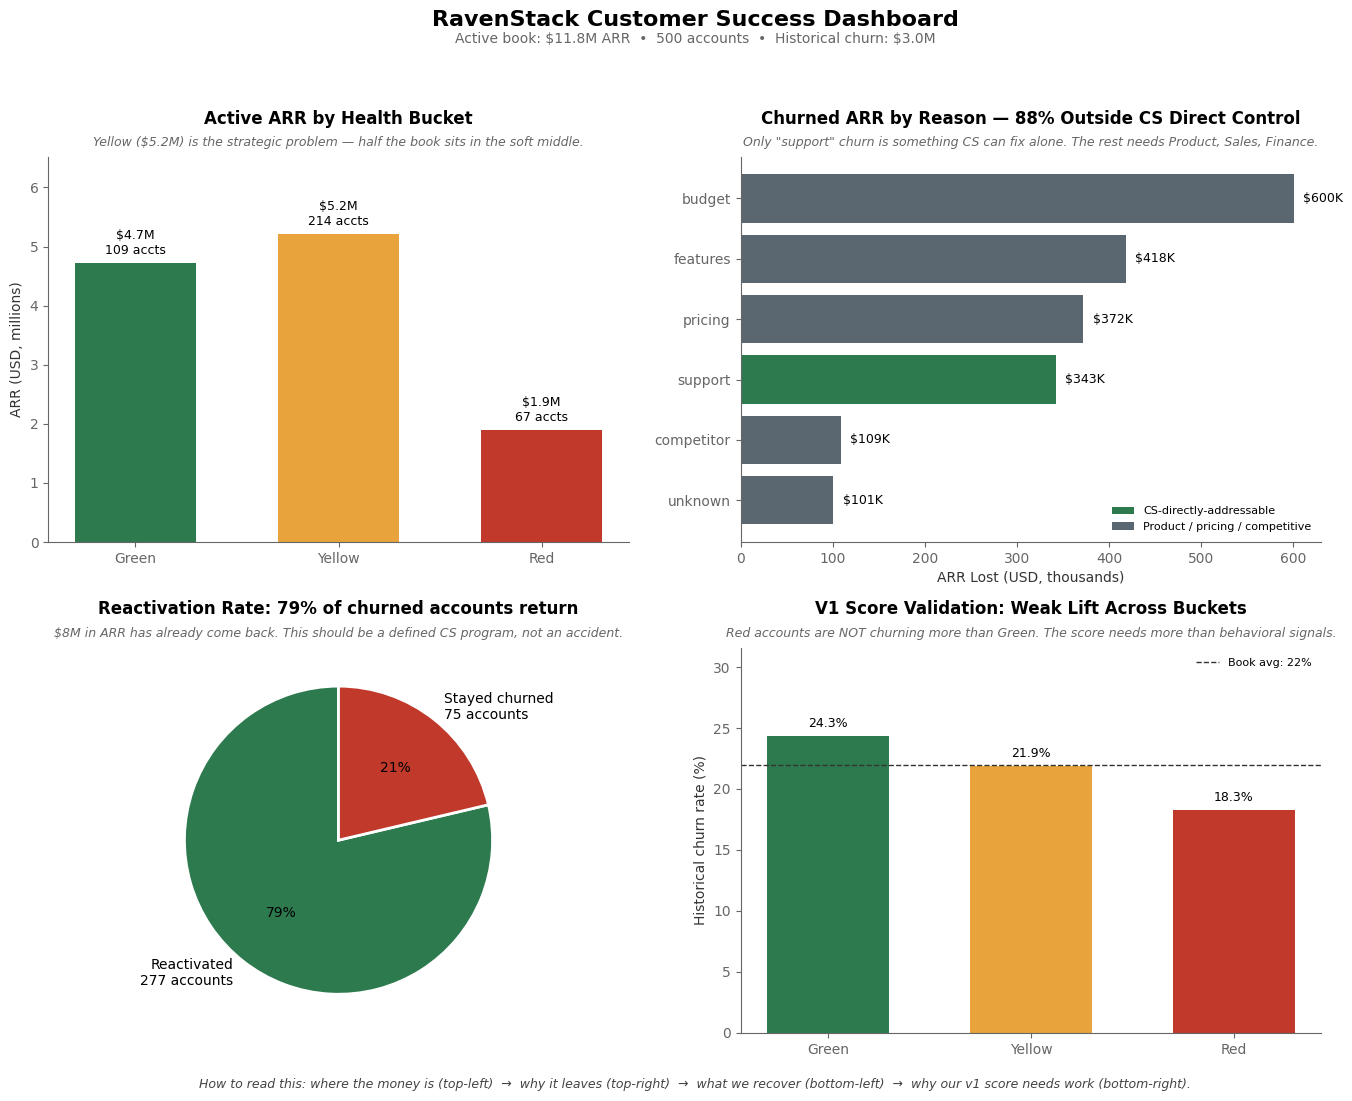

Saved to ../deliverables/dashboard.png


In [19]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import os

os.makedirs('../deliverables', exist_ok=True)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': '#666666',
    'axes.labelcolor': '#333333',
    'xtick.color': '#666666',
    'ytick.color': '#666666',
    'figure.facecolor': 'white',
    'mathtext.default': 'regular',
})

GREEN = '#2D7A4F'
YELLOW = '#E8A33D'
RED = '#C0392B'
NEUTRAL = '#5B6770'

fig = plt.figure(figsize=(14, 11))
fig.suptitle('RavenStack Customer Success Dashboard',
             fontsize=16, fontweight='bold', y=0.995)
fig.text(0.5, 0.965,
         r'Active book: \$11.8M ARR  •  500 accounts  •  Historical churn: \$3.0M',
         ha='center', fontsize=10, color='#666666')

# === Chart 1: ARR by health bucket ===
ax1 = plt.subplot(2, 2, 1)
active = master[~master['churn_flag']].copy()
bucket_order = ['Green', 'Yellow', 'Red']
arr_data = [active[active['health_bucket']==b]['arr_amount'].sum() for b in bucket_order]
count_data = [(active['health_bucket']==b).sum() for b in bucket_order]
colors = [GREEN, YELLOW, RED]
bars = ax1.bar(bucket_order, [a/1e6 for a in arr_data], color=colors, width=0.6)
ax1.set_title('Active ARR by Health Bucket', pad=24)
ax1.text(0.5, 1.02,
         'Yellow ($5.2M) is the strategic problem — half the book sits in the soft middle.',
         ha='center', va='bottom', transform=ax1.transAxes,
         fontsize=9, style='italic', color='#666666')
ax1.set_ylabel('ARR (USD, millions)')
for bar, arr, count in zip(bars, arr_data, count_data):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'\\${arr/1e6:.1f}M\n{count} accts',
             ha='center', va='bottom', fontsize=9)
ax1.set_ylim(0, max([a/1e6 for a in arr_data]) * 1.25)

# === Chart 2: Churn reason economics ===
ax2 = plt.subplot(2, 2, 2)
churned = master[master['churn_flag']].copy()
reason_arr = churned.groupby('last_reason_code')['arr_amount'].sum().sort_values(ascending=True).dropna()
addressable = ['support']
bar_colors = [GREEN if r in addressable else NEUTRAL for r in reason_arr.index]
bars2 = ax2.barh(reason_arr.index, reason_arr.values / 1e3, color=bar_colors)
ax2.set_title('Churned ARR by Reason — 88% Outside CS Direct Control', pad=24)
ax2.text(0.5, 1.02,
         'Only "support" churn is something CS can fix alone. The rest needs Product, Sales, Finance.',
         ha='center', va='bottom', transform=ax2.transAxes,
         fontsize=9, style='italic', color='#666666')
ax2.set_xlabel('ARR Lost (USD, thousands)')
for bar, val in zip(bars2, reason_arr.values):
    ax2.text(val/1e3 + 10, bar.get_y() + bar.get_height()/2,
             f'\\${val/1e3:.0f}K', va='center', fontsize=9)
ax2.legend(handles=[Patch(facecolor=GREEN, label='CS-directly-addressable'),
                    Patch(facecolor=NEUTRAL, label='Product / pricing / competitive')],
           loc='lower right', frameon=False, fontsize=8)

# === Chart 3: Reactivation story ===
ax3 = plt.subplot(2, 2, 3)
reactivated = int(((master['total_churn_events'] > 0) & (~master['churn_flag'])).sum())
still_churned = int(((master['total_churn_events'] > 0) & (master['churn_flag'])).sum())
ax3.pie([reactivated, still_churned],
        labels=[f'Reactivated\n{reactivated} accounts', f'Stayed churned\n{still_churned} accounts'],
        colors=[GREEN, RED], autopct='%1.0f%%', startangle=90,
        textprops={'fontsize': 10}, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax3.set_title(f'Reactivation Rate: {reactivated/(reactivated+still_churned)*100:.0f}% of churned accounts return',
              pad=24)
ax3.text(0.5, 1.02,
         '$8M in ARR has already come back. This should be a defined CS program, not an accident.',
         ha='center', va='bottom', transform=ax3.transAxes,
         fontsize=9, style='italic', color='#666666')

# === Chart 4: Score validation ===
ax4 = plt.subplot(2, 2, 4)
churn_rates = master.groupby('health_bucket')['churn_flag'].mean().reindex(bucket_order) * 100
benchmark = master['churn_flag'].mean() * 100
bars4 = ax4.bar(bucket_order, churn_rates.values, color=colors, width=0.6)
ax4.axhline(y=benchmark, color='#333333', linestyle='--', linewidth=1, label=f'Book avg: {benchmark:.0f}%')
ax4.set_title('V1 Score Validation: Weak Lift Across Buckets', pad=24)
ax4.text(0.5, 1.02,
         'Red accounts are NOT churning more than Green. The score needs more than behavioral signals.',
         ha='center', va='bottom', transform=ax4.transAxes,
         fontsize=9, style='italic', color='#666666')
ax4.set_ylabel('Historical churn rate (%)')
for bar, val in zip(bars4, churn_rates.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
ax4.legend(frameon=False, loc='upper right', fontsize=8)
ax4.set_ylim(0, max(churn_rates.values) * 1.3)

# Bottom footnote: tells the viewer how to read the dashboard
fig.text(0.5, 0.015,
         'How to read this: where the money is (top-left)  →  why it leaves (top-right)  →  '
         'what we recover (bottom-left)  →  why our v1 score needs work (bottom-right).',
         ha='center', fontsize=9, style='italic', color='#444444')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('../deliverables/dashboard.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved to ../deliverables/dashboard.png")